<a href="https://colab.research.google.com/github/Thorfast191/Monocular-Metric-Depth-Estimation/blob/main/MMDE_V1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MOUNT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load CSV

In [ ]:
import os
import pandas as pd

root = "/content/drive/MyDrive/Datasets/NYU Depth V2/nyu_data"

train_csv = os.path.join(root, "data/nyu2_train.csv")
test_csv  = os.path.join(root, "data/nyu2_test.csv")

# Load CSV
train_df = pd.read_csv(train_csv, header=None)
test_df  = pd.read_csv(test_csv, header=None)

train_df.columns = ['image', 'depth']
test_df.columns  = ['image', 'depth']

# Fix paths
train_df['image'] = train_df['image'].apply(lambda x: os.path.join(root, x))
train_df['depth'] = train_df['depth'].apply(lambda x: os.path.join(root, x))

test_df['image'] = test_df['image'].apply(lambda x: os.path.join(root, x))
test_df['depth'] = test_df['depth'].apply(lambda x: os.path.join(root, x))


In [ ]:
train_sample = train_df.sample(n=1600, random_state=42).reset_index(drop=True)
test_sample  = test_df.sample(n=400, random_state=42).reset_index(drop=True)

print("Train sample:", len(train_sample))
print("Test sample:", len(test_sample))

Train sample: 1600
Test sample: 400


# Data Pre-process

In [ ]:
import cv2
import numpy as np
import torch

def preprocess_sample(img_path, depth_path, size = (224, 224)):

    # =========================
    # 1. LOAD RGB
    # =========================
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # =========================
    # 2. LOAD DEPTH
    # =========================
    depth = cv2.imread(depth_path, -1)
    if depth is None:
        raise ValueError(f"Depth not found: {depth_path}")

    depth = depth.astype(np.float32)

    # =========================
    # 3. CONVERT TO METRIC (CRITICAL FIX)
    # =========================
    # Kaggle NYU: depth ~ [30, 255]
    # Map → [0.5m, 10m]

    depth_min = 30.0
    depth_max = 255.0

    real_min = 0.5   # meters
    real_max = 10.0  # meters

    depth = (depth - depth_min) / (depth_max - depth_min)
    depth = depth * (real_max - real_min) + real_min

    # =========================
    # 4. HANDLE INVALID VALUES
    # =========================
    mask = depth > 0

    # =========================
    # 5. RESIZE (DEPTH SAFE)
    # =========================
    img = cv2.resize(img, size)

    depth = cv2.resize(
        depth, size,
        interpolation=cv2.INTER_NEAREST
    )

    mask = cv2.resize(
        mask.astype(np.float32),
        size,
        interpolation=cv2.INTER_NEAREST
    )
    mask = mask > 0

    # =========================
    # 6. NORMALIZE RGB ONLY
    # =========================
    img = img.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img = (img - mean) / std

    # =========================
    # 7. TO TENSOR
    # =========================
    img = torch.from_numpy(img).permute(2, 0, 1).float()
    depth = torch.from_numpy(depth).float()
    mask = torch.from_numpy(mask).bool()

    return img, depth, mask

In [ ]:
# =========================
# VERIFY PREPROCESSING
# =========================

img, depth, mask = preprocess_sample(
    train_df.iloc[0]['image'],
    train_df.iloc[0]['depth']
)

print("Image shape:", img.shape)
print("Depth shape:", depth.shape)
print("Mask shape:", mask.shape)

print("Depth range:", depth.min().item(), depth.max().item())

Image shape: torch.Size([3, 240, 320])
Depth shape: torch.Size([240, 320])
Mask shape: torch.Size([240, 320])
Depth range: 0.5422222018241882 9.957777976989746


In [ ]:
from tqdm import tqdm

train_data = []
test_data = []

print("\nProcessing TRAIN data...")
for i in tqdm(range(len(train_sample))):
    img, depth, mask = preprocess_sample(
        train_sample.iloc[i]['image'],
        train_sample.iloc[i]['depth']
    )
    train_data.append((img, depth, mask))

print("\nProcessing TEST data...")
for i in tqdm(range(len(test_sample))):
    img, depth, mask = preprocess_sample(
        test_sample.iloc[i]['image'],
        test_sample.iloc[i]['depth']
    )
    test_data.append((img, depth, mask))



Processing TRAIN data...


100%|██████████| 1600/1600 [00:44<00:00, 35.57it/s]



Processing TEST data...


100%|██████████| 400/400 [00:16<00:00, 24.16it/s]


In [ ]:
train_imgs   = torch.stack([x[0] for x in train_data])
train_depths = torch.stack([x[1] for x in train_data])
train_masks  = torch.stack([x[2] for x in train_data])

test_imgs   = torch.stack([x[0] for x in test_data])
test_depths = torch.stack([x[1] for x in test_data])
test_masks  = torch.stack([x[2] for x in test_data])

print("\nFinal Shapes:")
print("Train Images:", train_imgs.shape)
print("Train Depths:", train_depths.shape)
print("Train Masks:", train_masks.shape)



Final Shapes:
Train Images: torch.Size([1600, 3, 240, 320])
Train Depths: torch.Size([1600, 240, 320])
Train Masks: torch.Size([1600, 240, 320])


In [ ]:
# =========================
# VERIFY PREPROCESSING
# =========================

img, depth, mask = preprocess_sample(
    train_df.iloc[0]['image'],
    train_df.iloc[0]['depth']
)

print("Image shape:", img.shape)
print("Depth shape:", depth.shape)
print("Mask shape:", mask.shape)

print("Depth range:", depth.min().item(), depth.max().item())

Image shape: torch.Size([3, 240, 320])
Depth shape: torch.Size([240, 320])
Mask shape: torch.Size([240, 320])
Depth range: 0.5422222018241882 9.957777976989746


# Visualization


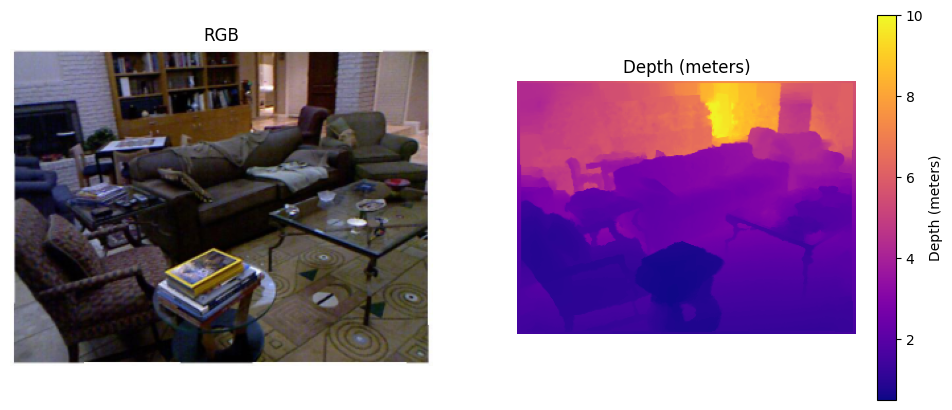

In [ ]:
import matplotlib.pyplot as plt

img_vis = img.permute(1,2,0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

img_vis = (img_vis * std) + mean
img_vis = np.clip(img_vis, 0, 1)

plt.figure(figsize=(12,5))

# RGB
plt.subplot(1,2,1)
plt.title("RGB")
plt.imshow(img_vis)
plt.axis("off")

# Depth with colorbar
plt.subplot(1,2,2)
plt.title("Depth (meters)")

im = plt.imshow(depth.numpy(), cmap='plasma', vmin=0.5, vmax=10)

cbar = plt.colorbar(im)
cbar.set_label("Depth (meters)")

plt.axis("off")
plt.show()

#  DataLoader

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_imgs, train_depths, train_masks)
test_dataset  = TensorDataset(test_imgs, test_depths, test_masks)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

#  DPT-Lite Model (timm ViT backbone)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class DPTLite(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            features_only=True
        )

        encoder_channels = self.encoder.feature_info.channels()

        self.reduce = nn.ModuleList([
            nn.Conv2d(ch, 256, 1) for ch in encoder_channels
        ])

        self.up4 = UpBlock(256, 256)
        self.up3 = UpBlock(512, 256)
        self.up2 = UpBlock(512, 128)
        self.up1 = UpBlock(384, 64)

        self.out_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        feats = self.encoder(x)
        feats = [r(f) for r, f in zip(self.reduce, feats)]

        f1, f2, f3, f4 = feats

        x = self.up4(f4)
        x = self.up3(x, f3)
        x = self.up2(x, f2)
        x = self.up1(x, f1)

        x = self.out_conv(x)

        depth = torch.exp(x)  # log-depth → depth

        return depth

# Loss Function (SILog)

In [ ]:
def silog_loss(pred, target, mask):
    pred = pred[mask]
    target = target[mask]

    log_diff = torch.log(pred) - torch.log(target)

    return torch.sqrt(
        (log_diff ** 2).mean() - 0.85 * (log_diff.mean() ** 2)
    )

# Training Loop

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = DPTLite().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for img, depth, mask in train_loader:

        img = img.to(device)
        depth = depth.to(device)
        mask = mask.to(device)

        pred = model(img).squeeze(1)

        loss = silog_loss(pred, depth, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

#  Evaluation Metrics

In [ ]:
def compute_metrics(pred, target, mask):

    pred = pred[mask]
    target = target[mask]

    # Avoid division issues
    pred = torch.clamp(pred, 1e-3, 10)
    target = torch.clamp(target, 1e-3, 10)

    # RMSE
    rmse = torch.sqrt(((pred - target) ** 2).mean())

    # AbsRel
    abs_rel = torch.mean(torch.abs(pred - target) / target)

    # Delta accuracy
    ratio = torch.max(pred / target, target / pred)

    d1 = (ratio < 1.25).float().mean()
    d2 = (ratio < 1.25**2).float().mean()
    d3 = (ratio < 1.25**3).float().mean()

    return rmse.item(), abs_rel.item(), d1.item(), d2.item(), d3.item()

model.eval()

rmse_total, absrel_total = 0, 0
d1_total, d2_total, d3_total = 0, 0, 0

count = 0

with torch.no_grad():
    for img, depth, mask in test_loader:

        img = img.to(device)
        depth = depth.to(device)
        mask = mask.to(device)

        pred = model(img).squeeze(1)

        rmse, absrel, d1, d2, d3 = compute_metrics(pred, depth, mask)

        rmse_total += rmse
        absrel_total += absrel
        d1_total += d1
        d2_total += d2
        d3_total += d3

        count += 1

print("\n===== TEST RESULTS =====")
print(f"RMSE   : {rmse_total/count:.4f}")
print(f"AbsRel : {absrel_total/count:.4f}")
print(f"δ1     : {d1_total/count:.4f}")
print(f"δ2     : {d2_total/count:.4f}")
print(f"δ3     : {d3_total/count:.4f}")